# 01 — Mendeley 274 EDA

Exploratory analysis of [Su et al. 2019](https://doi.org/10.17632/cxtph3tjsg.1) open cohort:
274 subjects with tongue, voice, pulse indices and eight constitution converted scores.

**Goal:** inventory the data, inspect score distributions, and reproduce correlation structure before ML baselines.

In [1]:
from tcm_constitution.adapters.mendeley_274 import load_mendeley_274
from tcm_constitution.viz.eda import (
    correlation_with_scores,
    plot_constitution_distributions,
    plot_correlation_heatmap,
    plot_primary_type_counts,
    summarize_cohort,
)

cohort = load_mendeley_274()
print(f"Loaded {cohort.n_subjects} subjects from {cohort.source_path.name}")

Loaded 274 subjects from Share data.xls


## 1. Data inventory

In [2]:
inventory = summarize_cohort(cohort)
inventory

,group,n_columns,missing_cells,n_subjects,source
0,demographics,9,0,274,Share data.xls
1,biosignals,54,52,274,Share data.xls
2,constitution_scores,8,0,274,Share data.xls


In [3]:
print("Demographics:", list(cohort.demographics.columns))
print("Biosignals:", len(cohort.biosignals.columns))
print("Constitution scores:", list(cohort.constitution_scores.columns))

Demographics: ['gender', 'age', 'education', 'occupation', 'chronic dz', 'surgery hx', 'BH', 'BW', 'BMI']
Biosignals: 54
Constitution scores: ['YaDC', 'YiDC', 'QDC', 'PDC', 'DHC', 'BSC', 'SDC', 'QSC']


## 2. Constitution score distributions

Eight biased-type converted scores (0–100). The Mendeley file does **not** include 平和质 (GTC); balanced subjects are inferred when all biased scores < 30.

In [4]:
cohort.constitution_scores.describe().round(1)

,YaDC,YiDC,QDC,PDC,DHC,BSC,SDC,QSC
count,274.0,274.0,274.0,274.0,274.0,274.0,274.0,274.0
mean,25.1,33.6,35.3,33.3,29.9,29.2,25.6,29.5
std,18.5,17.1,17.4,18.8,17.0,16.7,19.3,18.8
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,10.7,21.9,21.9,18.8,16.7,17.9,10.7,14.3
50%,21.4,34.4,34.4,31.2,29.2,28.6,21.4,28.6
75%,35.7,46.9,46.9,43.8,41.7,39.3,39.3,42.0
max,89.3,87.5,96.9,90.6,83.3,82.1,92.9,100.0


<Axes: title={'center': 'Constitution score distributions (Mendeley N=274)'}, ylabel='Converted score (0–100)'>

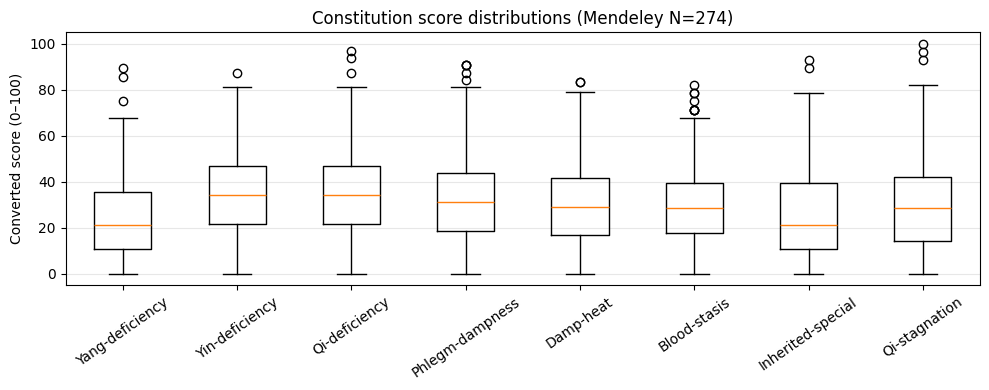

In [6]:
plot_constitution_distributions(cohort)

## 3. Derived primary type counts

In [7]:
enriched = cohort.with_primary_type()
enriched[["primary_label", "primary_status", "max_biased_score"]].head()

,primary_label,primary_status,max_biased_score
0,Yin-deficiency,yes,46.875000
1,Yang-deficiency,yes,67.857143
2,Damp-heat,yes,54.166667
3,Qi-stagnation,yes,57.142857
4,Damp-heat,yes,58.333333


<Axes: title={'center': 'Derived primary constitution (max biased score rule)'}, xlabel='primary_label', ylabel='Subjects'>

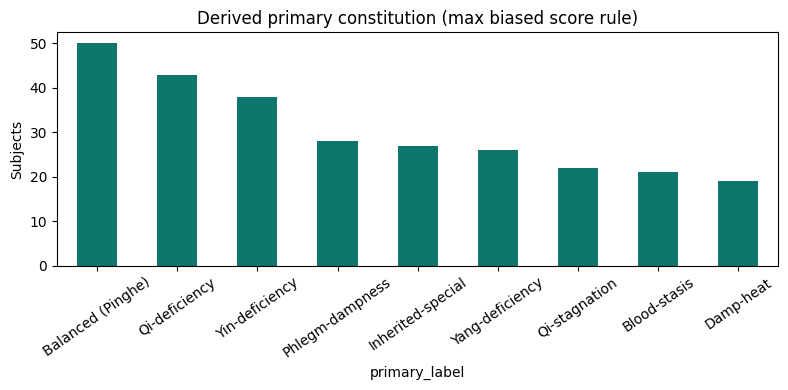

In [8]:
plot_primary_type_counts(cohort)

## 4. Feature ↔ score correlations

Pearson correlation between biosignal indices and constitution scores (Su et al. Table 2 narrative).

In [9]:
top_corr = correlation_with_scores(cohort, top_n=20)
top_corr

,feature,constitution,pearson_r,abs_r
229,AvgP,BSC,0.272646,0.272646
221,MaxP,BSC,0.264152,0.264152
237,MinP,BSC,0.251547,0.251547
225,AvgP,YiDC,0.216270,0.216270
217,MaxP,YiDC,0.211378,0.211378
102,RET L,SDC,-0.207685,0.207685
213,Intensity,BSC,-0.207309,0.207309
108,RET_R,DHC,-0.205252,0.205252
8,h2LBM,YaDC,-0.197927,0.197927
216,MaxP,YaDC,0.189655,0.189655


<Axes: title={'center': 'Top biosignal features vs constitution scores'}>

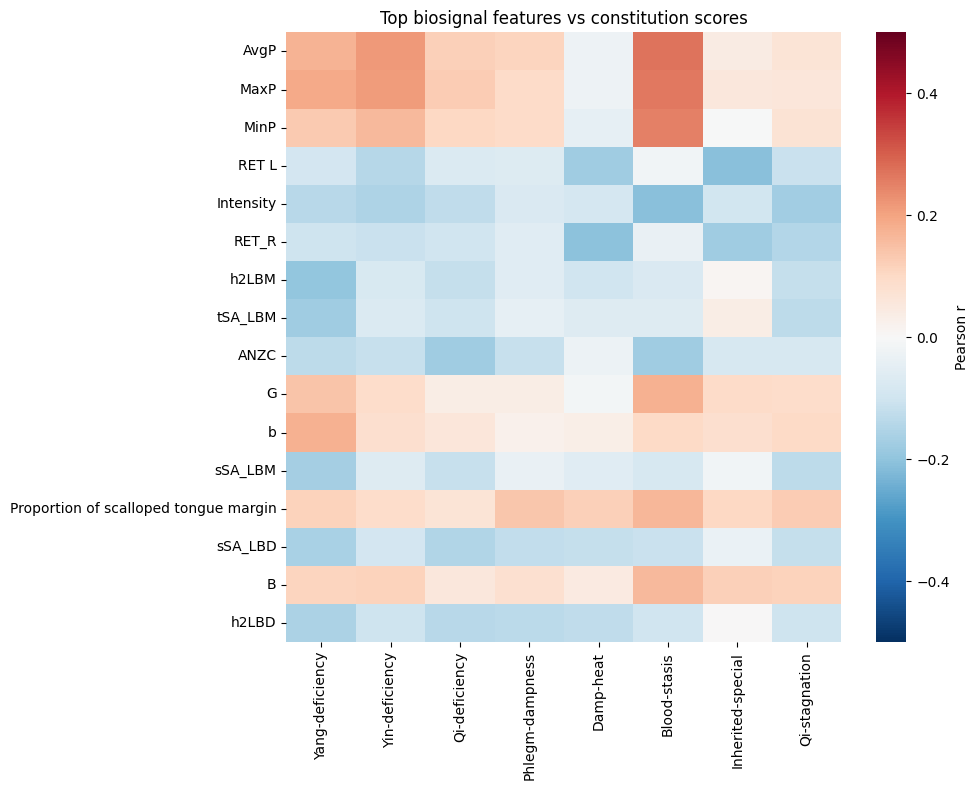

In [10]:
plot_correlation_heatmap(cohort, max_features=25)

## 5. Readiness summary

- **N=274** complete cases, **54** biosignal features, **8** constitution score targets
- Scores span 0–100; class imbalance expected (Qi-deficiency / Yin-deficiency common)
- Next: `02_reproduce_su2019.ipynb` — Ridge regression on scores + RF classifier on primary type